In [1]:
from google.colab import files
uploaded = files.upload()

Saving 01 Retail Inventory.xlsx to 01 Retail Inventory.xlsx


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1 – Data **Understanding**

1.1 Load Dataset

In [3]:
df = pd.read_excel("01 Retail Inventory.xlsx")

df.head()

,Product ID,Product Name,Category,Supplier Name,Unit Cost,Retail Price,Opening Stock,Units Sold,Closing Stock,Reorder Point,Stock Status
0,PRD-1001,Wine Glasses,Home & Kitchen,Heritage Brands,23.78,38.89,135,118,17,30,Low Stock
1,PRD-1002,Eye Mask,Beauty,Coastal Trading,15.67,24.53,86,10,76,9,In Stock
2,PRD-1003,Resistance Band,Sports & Outdoors,National Supply Group,5.59,11.88,319,195,124,47,In Stock
3,PRD-1004,Action Figure,Toys & Games,Pacific Wholesale,9.72,18.01,173,140,33,39,Low Stock
4,PRD-1005,Serving Tray,Home & Kitchen,Coastal Trading,8.22,13.90,32,8,24,7,In Stock


1.2 Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product ID     1000 non-null   object 
 1   Product Name   1000 non-null   object 
 2   Category       1000 non-null   object 
 3   Supplier Name  1000 non-null   object 
 4   Unit Cost      1000 non-null   float64
 5   Retail Price   1000 non-null   float64
 6   Opening Stock  1000 non-null   int64  
 7   Units Sold     1000 non-null   int64  
 8   Closing Stock  1000 non-null   int64  
 9   Reorder Point  1000 non-null   int64  
 10  Stock Status   1000 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


1.3 Missing Values Check

In [5]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


CONCLUSION : The dataset contains 1000 inventory records and 11 attributes. All columns have complete data with no missing values. The dataset includes both numerical and categorical variables, making it suitable for inventory analysis and further exploratory data analysis.

# **TASK 2 Data Cleaning**







2.1 Duplicate Check

In [6]:
df.duplicated().sum()

np.int64(0)

2.2 Missing Values

In [7]:
df.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier Name,0
Unit Cost,0
Retail Price,0
Opening Stock,0
Units Sold,0
Closing Stock,0
Reorder Point,0


2.3 Stock Validation

In [8]:
df[['Opening Stock','Units Sold','Closing Stock','Reorder Point']].describe()

,Opening Stock,Units Sold,Closing Stock,Reorder Point
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,262.451000,137.040000,125.411000,44.98300
std,140.104457,103.623232,99.023521,27.54468
min,20.000000,3.000000,4.000000,2.00000
25%,141.750000,53.000000,44.000000,22.00000
50%,261.000000,108.500000,96.000000,41.00000
75%,388.000000,204.000000,190.000000,64.25000
max,499.000000,463.000000,432.000000,119.00000


CONCLUSION : No duplicate records were found in the dataset. No missing values were detected, so no data cleaning was required. Validation of stock-related fields showed that all values are positive and within reasonable ranges. Therefore, the dataset is clean and ready for analysis.

# Task 3 – Exploratory Data **Analysis**

3.1 Category-wise Product Count

In [9]:
df['Category'].value_counts()

,count
Category,
Beauty,134
Sports & Outdoors,132
Electronics,126
Office Supplies,126
Home & Kitchen,124
Toys & Games,123
Grocery,119
Clothing,116


3.2 Category-wise Units Sold

In [10]:
df.groupby('Category')['Units Sold'].sum().sort_values(ascending=False)

,Units Sold
Category,
Toys & Games,19704
Home & Kitchen,18387
Beauty,18137
Electronics,17621
Office Supplies,17112
Sports & Outdoors,16979
Grocery,15364
Clothing,13736


3.3 Top 10 Best Selling Products

In [11]:
top10 = df.sort_values('Units Sold', ascending=False)

top10[['Product Name','Units Sold']].head(10)

,Product Name,Units Sold
721,Water Bottle,463
476,Canned Soup,456
791,Coffee Mug Set,435
673,LED Desk Lamp,432
810,Coloring Set,428
243,Notebook A5,423
970,Baseball Cap,422
550,Whistle,422
931,Rice Crackers,417
469,Building Blocks,416


3.4 Top 10 Low Stock Products

In [12]:
lowstock = df.sort_values('Closing Stock')

lowstock[['Product Name','Closing Stock']].head(10)

,Product Name,Closing Stock
45,Basic T-Shirt,4
385,Coloring Set,4
819,Notebook A5,4
654,Storage Container,4
425,Nail File Set,5
391,Eye Mask,5
703,Coffee Mug Set,5
977,Cotton Pads,6
698,Whistle,6
709,Dry Shampoo,6


3.5 Supplier-wise Inventory Distribution

In [13]:
df['Supplier Name'].value_counts()

,count
Supplier Name,
Premier Merchandise,119
National Supply Group,116
Heritage Brands,109
Coastal Trading,103
Global Source Direct,103
United Imports,99
Pacific Wholesale,98
Summit Wholesale Inc,92
Metro Distributors,89


CONCLUSION: The analysis identified the most popular product categories, best-selling products, low-stock items, and supplier contributions. The results provide valuable insights into inventory performance and help in making stock replenishment and supplier management decisions.

# Task 4 – **Charts**

4.1 Bar Chart

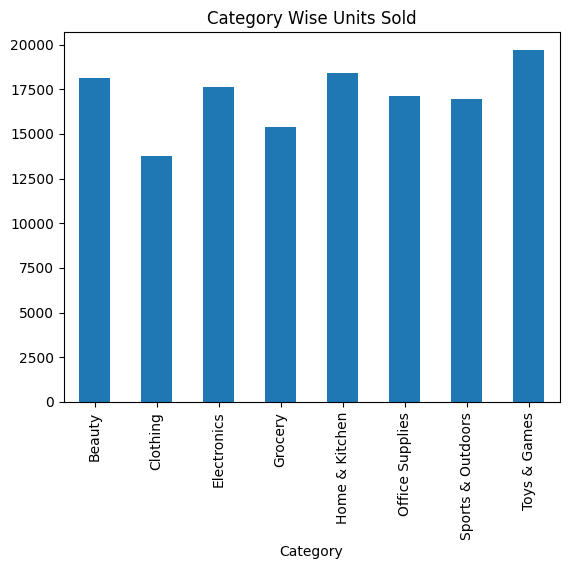

In [14]:
category_sales = df.groupby('Category')['Units Sold'].sum()

category_sales.plot(kind='bar')
plt.title("Category Wise Units Sold")
plt.show()

4.2 Pie Chart

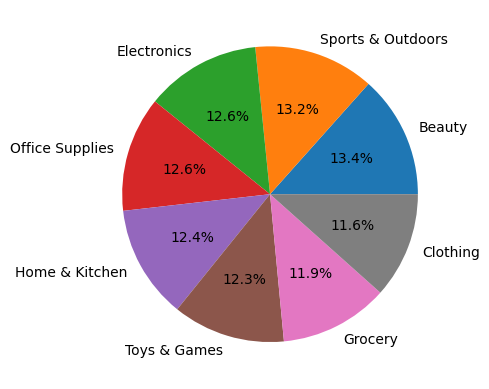

In [15]:
df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.show()

4.3 Histogram

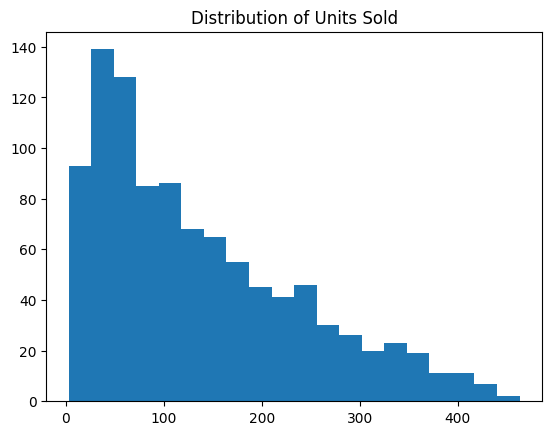

In [16]:
plt.hist(df['Units Sold'], bins=20)
plt.title("Distribution of Units Sold")
plt.show()

4.4 Line Graph

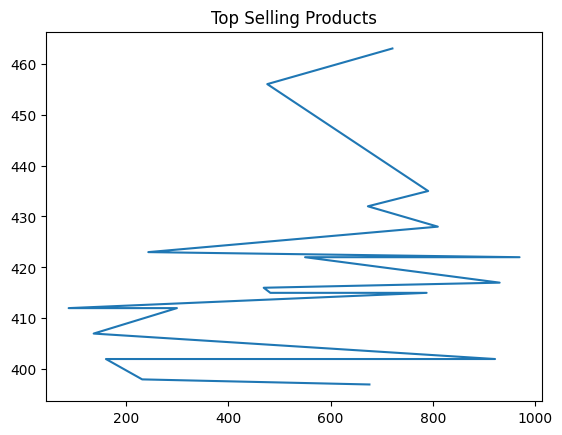

In [17]:
top = df.sort_values('Units Sold', ascending=False).head(20)

plt.plot(top['Units Sold'])
plt.title("Top Selling Products")
plt.show()

4.5 Heatmap (Bonus)

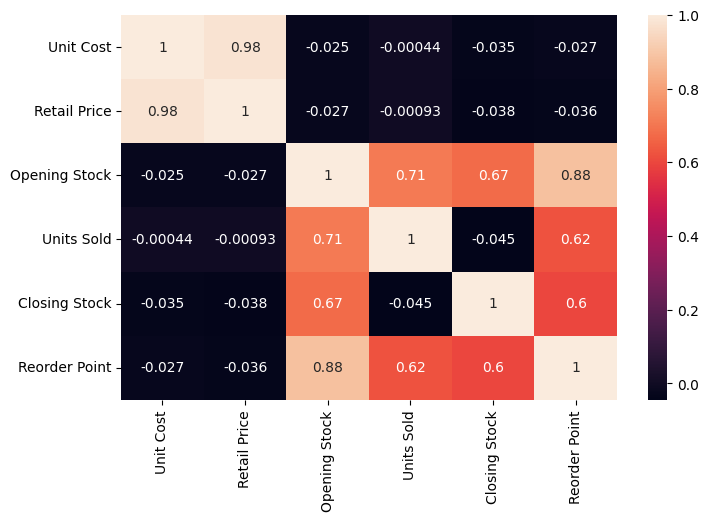

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Unit Cost',
        'Retail Price',
        'Opening Stock',
        'Units Sold',
        'Closing Stock',
        'Reorder Point']].corr(),
    annot=True
)

plt.show()

CONCLUSION:Data visualizations helped in understanding sales trends, stock distribution, category performance, and relationships between inventory variables. The charts provide a clear and effective representation of inventory data, supporting better business decision-making.

# Task 5 – Business Insights

### 5.1 Products Requiring Immediate Replenishment

Products with the lowest closing stock levels are approaching reorder points and should be restocked immediately to avoid stock shortages.

### 5.2 Fast-Moving Product Categories

Categories with the highest units sold demonstrate strong customer demand and require frequent inventory monitoring.

### 5.3 Relationship Between Stock and Sales

Products with higher sales generally show lower closing stock levels, indicating that demand has a direct impact on inventory availability.

### 5.4 Supplier Contribution Analysis

A few suppliers contribute a significant portion of the inventory, indicating dependency on limited suppliers.

### 5.5 Inventory Optimization Opportunity

Slow-moving products remain in stock for longer periods and may require promotional strategies or adjusted purchasing decisions.

### 5.6 Business Recommendation

The company should implement automatic reorder alerts, regularly monitor fast-selling products, and diversify suppliers to improve inventory management efficiency.


# Final Conclusion

The Retail Inventory Analytics project successfully analyzed inventory data using Python and Google Colab. Data cleaning confirmed that the dataset contained no missing values or duplicate records. Exploratory analysis and visualizations helped identify sales trends, inventory patterns, supplier contributions, and low-stock products. The insights generated from this analysis can support better inventory planning, supplier management, and business decision-making.
